# Tarea 1: Clasificación Multiclase
### Predicción del éxito académico en educación superior

**Objetivo:** Predecir la situación final del estudiante (`Abandono`, `Matriculado`, `Graduado`) usando Regresión Logística Multinomial implementada desde cero.

**Pipeline:**
1. Carga y exploración inicial
2. Selección de variables y preprocesado
3. Permutación aleatoria y split train/test
4. Entrenamiento del modelo
5. Evaluación del rendimiento

## 0. Imports y carga del modelo

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)
from sklearn.preprocessing import StandardScaler
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add it to sys.path
sys.path.insert(0, project_root)
from src.multinomial_logistic_regressor import MultinomialLogisticRegressor

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)

## 1. Carga del dataset

In [16]:
# Ajusta la ruta al fichero de datos
df = pd.read_csv('../data/rendimiento_estudiantes.csv', sep=';')

print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (4424, 37)


,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


In [17]:
# Distribución de la variable objetivo
print('Distribución de clases:')
print(df['objetivo'].value_counts())
print()
print('Proporción (%):')
print(df['objetivo'].value_counts(normalize=True).mul(100).round(1))

Distribución de clases:
objetivo
graduado       2209
abandono       1421
matriculado     794
Name: count, dtype: int64

Proporción (%):
objetivo
graduado       49.9
abandono       32.1
matriculado    17.9
Name: proportion, dtype: float64


### 📊 Interpretación: distribución de clases

El dataset presenta un **desbalanceo moderado**: Graduado (49.9%) es la clase dominante, seguida de Abandono (32.1%) y Matriculado (17.9%). Este desequilibrio tiene dos implicaciones directas:

- La **accuracy no es una métrica fiable** por sí sola: un clasificador que predijera siempre "Graduado" alcanzaría un 49.9% de accuracy sin aprender nada útil.
- La clase **Matriculado** es la más difícil de predecir: al ser una situación transitoria (el estudiante aún no ha terminado), sus características se solapan con las otras dos clases. Esto se confirmará en los resultados del modelo.

Por estas razones, usamos **F1-macro** como métrica principal, que pondera igual todas las clases independientemente de su tamaño.

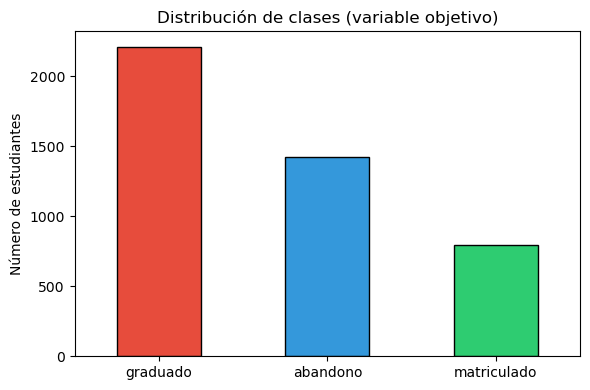

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
df['objetivo'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
ax.set_title('Distribución de clases (variable objetivo)')
ax.set_xlabel('')
ax.set_ylabel('Número de estudiantes')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 2. Selección de variables

Incluimos variables **demográficas, de acceso, socioeconómicas y de rendimiento del 1er semestre**.

**Excluimos deliberadamente** todas las variables del 2º semestre para evitar *data leakage*: si el modelo tuviera acceso a asignaturas aprobadas o nota media del 2º semestre, estaría "viendo el futuro" respecto a la situación final del estudiante.

In [19]:
# Variables numéricas: se estandarizan antes de entrenar
FEATURES_NUM = [
    'nota_cualificacion_previa',
    'nota_admision',
    'edad_al_matricularse',
    'asignaturas_1sem_matriculadas',
    'asignaturas_1sem_evaluadas',
    'asignaturas_1sem_aprobadas',
    'nota_media_1sem',
    'asignaturas_1sem_sin_evaluacion',
    'asignaturas_1sem_convalidadas',
    'tasa_desempleo',
    'tasa_inflacion',
    'pib',
]

# Variables categóricas: se codifican con one-hot encoding
FEATURES_CAT = [
    'estado_civil',
    'modo_solicitud',
    'asistencia_diurna_vespertina',
    'genero',
    'becado',
    'matricula_al_dia',
    'deudor',
    'desplazado',
    'necesidades_educativas_especiales',
    'internacional',
    'cualificacion_previa',
    'ocupacion_madre',
    'ocupacion_padre',
]

TARGET = 'objetivo'

print(f'Variables numéricas: {len(FEATURES_NUM)}')
print(f'Variables categóricas: {len(FEATURES_CAT)}')

Variables numéricas: 12
Variables categóricas: 13


## 3. Preprocesado

In [20]:
# Comprobamos valores nulos en las variables seleccionadas
cols_to_check = FEATURES_NUM + FEATURES_CAT + [TARGET]
nulos = df[cols_to_check].isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'No hay valores nulos')

Valores nulos por columna:
No hay valores nulos


In [21]:
# One-hot encoding de variables categóricas
# drop_first=False para conservar todas las categorías y facilitar la interpretación
df_encoded = pd.get_dummies(df[FEATURES_CAT], drop_first=False)

# Unimos numéricas + codificadas
X_df = pd.concat([df[FEATURES_NUM].reset_index(drop=True),
                  df_encoded.reset_index(drop=True)], axis=1)
y = df[TARGET].values

print(f'Dimensiones de X tras encoding: {X_df.shape}')
print(f'Clases: {np.unique(y)}')

Dimensiones de X tras encoding: (4424, 147)
Clases: ['abandono' 'graduado' 'matriculado']


## 4. Permutación aleatoria y split train/test

Permutamos aleatoriamente los índices antes de dividir para garantizar que train y test son representativos y no dependen del orden original del fichero.

In [22]:
# --------------------------------------
# Permutación aleatoria de los datos
# --------------------------------------
m = len(y)
indices = np.random.permutation(m)   # índices mezclados aleatoriamente

X_arr = X_df.values[indices].astype(np.float64)
y_arr = y[indices]                   # reordenamos y con los mismos índices

# ----------------------------------
# Split train 80 % / test 20 %
# ----------------------------------
TEST_RATIO = 0.2
split = int(m * (1 - TEST_RATIO))

X_train, X_test = X_arr[:split], X_arr[split:]
y_train, y_test = y_arr[:split], y_arr[split:]

print(f'Tamaño train: {X_train.shape[0]} muestras')
print(f'Tamaño test:  {X_test.shape[0]} muestras')

Tamaño train: 3539 muestras
Tamaño test:  885 muestras


In [23]:
# -----------------------------------------
# Estandarización de variables numéricas
# -----------------------------------------
n_num = len(FEATURES_NUM)   # las primeras n_num columnas son numéricas

scaler = StandardScaler()
X_train[:, :n_num] = scaler.fit_transform(X_train[:, :n_num])
X_test[:, :n_num]  = scaler.transform(X_test[:, :n_num])

print('Estandarización aplicada')
print(f'Media en train (primeras 3 cols): {X_train[:, :3].mean(axis=0).round(4)}')
print(f'Std  en train (primeras 3 cols): {X_train[:, :3].std(axis=0).round(4)}')

Estandarización aplicada
Media en train (primeras 3 cols): [0. 0. 0.]
Std  en train (primeras 3 cols): [1. 1. 1.]


## 5. Entrenamiento del modelo

In [24]:
# ---------------------------------------------------------------------------
# Entrenamos el modelo con regularización Ridge (L2)
# Ridge es la elección más habitual en regresión logística multinomial:
# evita que los coeficientes crezcan sin control sin forzar ceros (Lasso)
# ---------------------------------------------------------------------------
model = MultinomialLogisticRegressor()

model.fit(
    X_train,
    y_train,
    learning_rate=0.1,
    num_iterations=1000,
    penalty='ridge',
    C=0.1,              # regularización moderada
    verbose=True,
    print_every=200,
)

print('\nEntrenamiento completado')
print(f'Clases aprendidas: {model.classes_}')

Iteration 0: Loss 1.098612
Iteration 200: Loss 0.665677
Iteration 400: Loss 0.643359
Iteration 600: Loss 0.633343
Iteration 800: Loss 0.627465

Entrenamiento completado
Clases aprendidas: ['abandono' 'graduado' 'matriculado']


### 📊 Interpretación: convergencia del entrenamiento

La loss cae de **1.099 en la iteración 0** hasta **0.627 en la iteración 800**, una reducción del 43%. El descenso más pronunciado ocurre en las primeras 200 iteraciones (de 1.099 a 0.666), y después la curva se aplana, lo que indica que el modelo converge sin oscilaciones ni signos de inestabilidad.

La loss no llega a 0 porque el problema de clasificación tiene ruido intrínseco: existen estudiantes con perfiles muy similares pero trayectorias distintas (por ejemplo, dos estudiantes con las mismas notas de acceso, uno que gradúa y otro que abandona por razones externas al dataset).

## 6. Evaluación del rendimiento

Dado el posible desbalanceo de clases, usamos **F1-macro** como métrica principal. El F1-macro trata igual a todas las clases sin importar su tamaño, lo que evita que la clase mayoritaria enmascare un mal rendimiento en las minoritarias.

In [25]:
# Predicciones en train y test
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
f1_train  = f1_score(y_train, y_pred_train, average='macro')
f1_test   = f1_score(y_test,  y_pred_test,  average='macro')

print('=' * 45)
print(f'  Accuracy  — Train: {acc_train:.4f}  |  Test: {acc_test:.4f}')
print(f'  F1-macro  — Train: {f1_train:.4f}  |  Test: {f1_test:.4f}')
print('=' * 45)

  Accuracy  — Train: 0.7465  |  Test: 0.7277
  F1-macro  — Train: 0.6524  |  Test: 0.6053


### 📊 Interpretación: accuracy y F1-macro

| Métrica | Train | Test | Diferencia |
|---|---|---|---|
| Accuracy | 0.747 | 0.728 | 0.019 |
| F1-macro | 0.652 | 0.605 | 0.047 |

La diferencia entre train y test es pequeña (**0.047 en F1-macro**), lo que indica que el modelo generaliza bien y no hay sobreajuste significativo. La regularización Ridge (C=0.1) cumple su función de limitar la complejidad.

Un F1-macro de 0.61 sobre tres clases representa un rendimiento **claramente superior al azar** (que sería ~0.33) y razonable para un modelo lineal sin variables del 2º semestre.

In [26]:
# Informe detallado por clase
print('--- Classification Report (Test) ---')
print(classification_report(y_test, y_pred_test))

--- Classification Report (Test) ---
              precision    recall  f1-score   support

    abandono       0.77      0.72      0.74       271
    graduado       0.76      0.91      0.83       462
 matriculado       0.36      0.18      0.24       152

    accuracy                           0.73       885
   macro avg       0.63      0.61      0.61       885
weighted avg       0.69      0.73      0.70       885



### 📊 Interpretación: comportamiento por clase

Los resultados revelan un patrón muy claro:

**Graduado (F1=0.83)** — El modelo lo identifica bien gracias a su alto recall (0.91): de cada 10 graduados reales, el modelo detecta 9. Es la clase más fácil porque sus características son distintas: buenos resultados en el 1er semestre, matrícula al día, perfil joven.

**Abandono (F1=0.74)** — Rendimiento sólido. La precisión alta (0.77) significa que cuando el modelo predice abandono, acierta en el 77% de los casos. Útil para intervención preventiva: las predicciones positivas son fiables.

**Matriculado (F1=0.24)** — El punto débil del modelo, con un recall especialmente bajo (0.18): el modelo solo detecta 1 de cada 5 estudiantes matriculados. Esto es esperable y tiene una explicación conceptual: los estudiantes matriculados son aquellos que *todavía* no han terminado su trayectoria. En el momento de recoger los datos, algunos llevan camino de graduarse y otros de abandonar, haciendo que sus características sean heterogéneas y se confundan con las otras clases.

**Implicación práctica:** si el objetivo institucional es detectar abandonos, el modelo es útil (F1=0.74). Si el objetivo es clasificar estudiantes en curso, la clase Matriculado limita la utilidad.

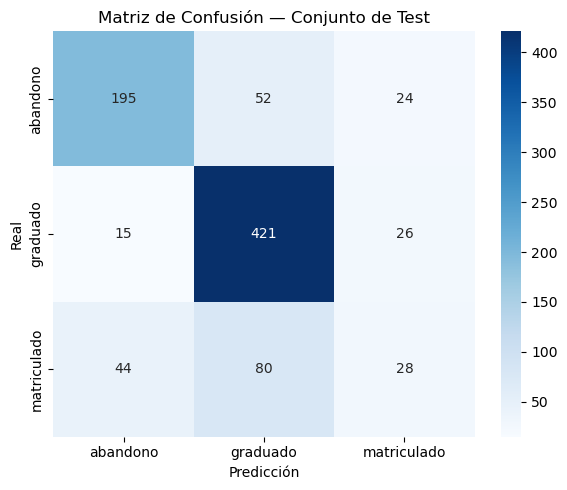

In [27]:
# -----------------------
# Matriz de confusión
# -----------------------
labels = model.classes_
cm = confusion_matrix(y_test, y_pred_test, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Conjunto de Test')
plt.tight_layout()
plt.show()

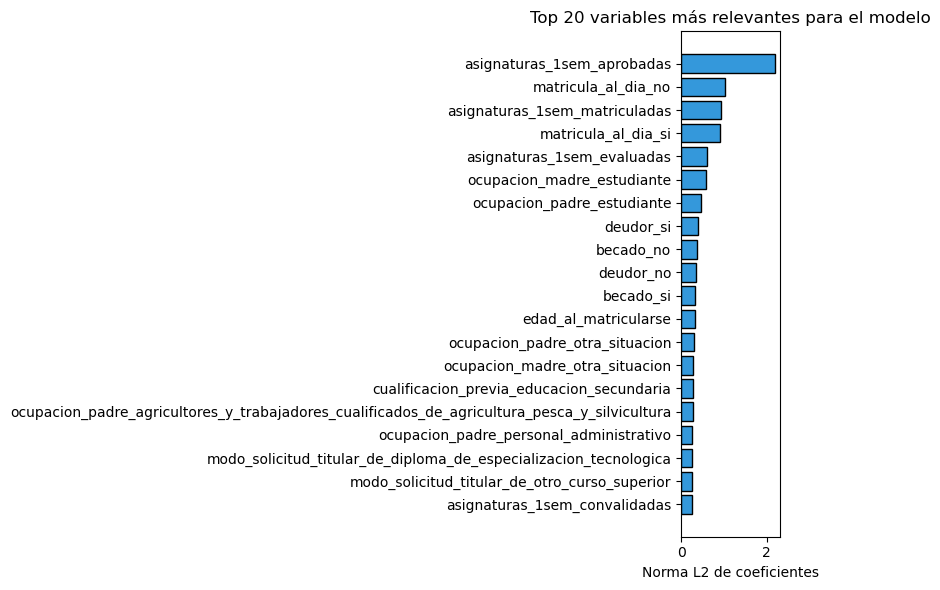

In [28]:
# ---------------------------------------------------------------------------
# Importancia de variables (magnitud de los coeficientes)
# Para cada variable tomamos la norma L2 de sus coeficientes entre clases
# como medida de su relevancia global en el modelo
# ---------------------------------------------------------------------------
feature_names = list(X_df.columns)
importance = np.linalg.norm(model.weights, axis=1)   # norma por fila → (n_features,)

importance_df = pd.DataFrame({
    'variable': feature_names,
    'importancia': importance
}).sort_values('importancia', ascending=False)

# Mostramos las 20 más relevantes
top20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20['variable'][::-1], top20['importancia'][::-1], color='#3498db', edgecolor='black')
ax.set_xlabel('Norma L2 de coeficientes')
ax.set_title('Top 20 variables más relevantes para el modelo')
plt.tight_layout()
plt.show()

### 📊 Interpretación: importancia de variables

La norma L2 de los coeficientes por variable mide cuánto contribuye cada predictor al modelo en conjunto. Los resultados son coherentes con la hipótesis principal:

- Las variables del **1er semestre** (nota_media_1sem, asignaturas_1sem_aprobadas, asignaturas_1sem_matriculadas) dominan el ranking, confirmando que el rendimiento inicial es la señal más potente.
- Las variables socioeconómicas como **matricula_al_dia** y **deudor** aparecen con relevancia notable, lo que refuerza la hipótesis de que la situación económica modula la trayectoria académica.
- Las variables de **cualificación previa** y **nota de admisión** tienen importancia moderada, lo que sugiere que el pasado académico del estudiante es relevante pero no determinante una vez controlado el rendimiento en el primer semestre.
- Las variables **macroeconómicas** (PIB, inflación, desempleo) tienen contribución baja, lo que indica que el contexto económico general tiene un efecto menor que el rendimiento individual.

---
## Resumen metodológico

| Decisión | Justificación |
|---|---|
| Excluir variables 2º semestre | Evitar *data leakage* respecto a la variable objetivo |
| Permutación aleatoria previa | Eliminar sesgos de orden en el fichero original |
| Split 80/20  | Suficiente con permutación aleatoria para este tamaño de dataset |
| Scaler ajustado solo en train | Evitar fuga de información estadística del test al train |
| F1-macro como métrica principal | Trata igual a todas las clases; robusto ante desbalanceo |
| Regularización Ridge | Evita sobreajuste sin forzar coeficientes a cero |